**Goal:** first contact with GeoPandas -- load Puerto Rico's official
municipio boundaries and the USGS catalog of the 2019-2020 earthquake
sequence, fix the coordinate problem, and combine the two layers into maps
that answer "where did it hit?". Pairs with the concept note
[Mapping Puerto Rico: Spatial Data with GeoPandas](l12_concept_spatial_geopandas.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l12_lab_mapping_earthquakes.ipynb`) -- in Colab via the badge on the
> concept page, or locally.

## Prerequisites & Setup

Run this first. Two public-domain datasets, both bundled with the course and
both with live download fallbacks:

- **Municipio boundaries:** US Census Bureau cartographic boundary file
  (county subdivisions for Puerto Rico, 1:500k generalized).
- **Earthquakes:** USGS Earthquake Catalog API -- every magnitude-3.5+ event
  near Puerto Rico from 2019-12-28 to 2020-01-31, as GeoJSON. Note the
  fallback URL: it is a plain web API with query parameters, exactly the
  L04 pattern.

There is no randomness in this lab -- maps and measurements are fully
deterministic, so no seed is needed.

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q geopandas pandas matplotlib

import os
import urllib.request
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# US Census Bureau cartographic boundary file (public domain)
BOUNDS_LOCAL = "data/cb_2023_72_cousub_500k.zip"
BOUNDS_URL = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_72_cousub_500k.zip"

# USGS Earthquake Catalog API (public domain)
QUAKES_LOCAL = "data/pr_quakes_2020.geojson"
QUAKES_URL = ("https://earthquake.usgs.gov/fdsnws/event/1/query"
              "?format=geojson&starttime=2019-12-28&endtime=2020-01-31"
              "&minmagnitude=3.5&minlatitude=17.5&maxlatitude=18.7"
              "&minlongitude=-67.5&maxlongitude=-65.2")

for local, url in [(BOUNDS_LOCAL, BOUNDS_URL), (QUAKES_LOCAL, QUAKES_URL)]:
    if not os.path.exists(local):
        os.makedirs("data", exist_ok=True)
        urllib.request.urlretrieve(url, local)

barrios = gpd.read_file(BOUNDS_LOCAL)
quakes = gpd.read_file(QUAKES_LOCAL)
print("Subdivisions:", barrios.shape)
print("Earthquakes: ", quakes.shape)

Note: you may need to restart the kernel to use updated packages.


Subdivisions: (901, 15)
Earthquakes:  (250, 28)


<details><summary>Expected Output</summary>

~~~text
Subdivisions: (901, 15)
Earthquakes:  (250, 28)
~~~
</details>

## Step 1: First Look -- a Table Stapled to a Map (Worked)

Both objects are GeoDataFrames: ordinary columns plus one `geometry` column
holding shapes. The boundary file's rows are *county subdivisions* (barrios);
the column `NAMELSADCO` says which municipio each barrio belongs to.

In [2]:
print(barrios[["NAME", "NAMELSADCO"]].head(3))
print()
print("The geometry column:")
print(barrios.geometry.head(2))
print()
print("Boundaries CRS:", barrios.crs)
print("Quakes CRS:    ", quakes.crs)

        NAME          NAMELSADCO
0     Arroyo    Arroyo Municipio
1    Hatillo    Añasco Municipio
2  Algarrobo  Aibonito Municipio

The geometry column:
0    POLYGON ((-66.066 17.964, -66.065 17.965, -66....
1    POLYGON ((-67.199 18.299, -67.197 18.305, -67....
Name: geometry, dtype: geometry

Boundaries CRS: EPSG:4269
Quakes CRS:     EPSG:4979


<details><summary>Expected Output</summary>

~~~text
        NAME          NAMELSADCO
0     Arroyo    Arroyo Municipio
1    Hatillo    Añasco Municipio
2  Algarrobo  Aibonito Municipio

The geometry column:
0    POLYGON ((-66.066 17.964, -66.065 17.965, -66....
1    POLYGON ((-67.199 18.299, -67.197 18.305, -67....
Name: geometry, dtype: geometry

Boundaries CRS: EPSG:4269
Quakes CRS:     EPSG:4979
~~~
</details>

> **Read it:** three things. First, row 1 is a barrio named "Hatillo" that
> belongs to *Anasco* Municipio -- there is also a whole municipio called
> Hatillo elsewhere. Barrio names repeat across the island, which is exactly
> why the municipio column, not the name, will be our grouping key. Second,
> each geometry is a polygon: a closed chain of longitude/latitude corners.
> Third, the two layers arrive on *different* coordinate systems (EPSG:4269
> and EPSG:4979 -- both in degrees) -- remember that for Step 4.

## Step 2: The Coordinate Problem (Worked + Completion)

The concept note's claim: measuring in degrees produces nonsense. Watch it
happen -- ask for the total area while the data is still in the shipped CRS:

In [3]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    total_deg = barrios.geometry.area.sum()

print(f"Total 'area' in the shipped CRS: {total_deg:.4f}")
print()
print("And geopandas itself objects:")
print(" ", caught[0].message)

Total 'area' in the shipped CRS: 0.7626

And geopandas itself objects:
  Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



<details><summary>Expected Output</summary>

~~~text
Total 'area' in the shipped CRS: 0.7626

And geopandas itself objects:
  Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.
~~~
</details>

> **Read it:** Puerto Rico is apparently 0.76 of... something. The unit is
> "square degrees", which is not a unit of area -- a degree of longitude is
> about 111 km at the equator and shrinks toward the poles. The library knows
> this and tells you so. The fix is one line: reproject to a CRS measured in
> meters (for Puerto Rico, EPSG:32161).

Now do it right: merge the 901 barrios into municipios with `dissolve`, then
reproject and measure.

In [4]:
municipios = barrios.dissolve(by="NAMELSADCO").reset_index()
municipios = municipios.to_crs(epsg=32161)
municipios["area_km2"] = municipios.geometry.area / 1e6

print("Municipios:", len(municipios))
print(f"Total area: {municipios['area_km2'].sum():,.0f} km2")

Municipios: 78
Total area: 8,928 km2


<details><summary>Expected Output</summary>

~~~text
Municipios: 78
Total area: 8,928 km2
~~~
</details>

> **Read it:** `dissolve(by=...)` is groupby for shapes -- it merges all
> geometries sharing a value into one polygon per group, and 901 barrios
> collapse into exactly **78 municipios**, the number every Puerto Rican
> knows. After `to_crs(epsg=32161)` the same `.area` call returns real
> square meters, and the island totals 8,928 km2 -- a number you can check
> against any almanac.

Your turn -- which municipio is the largest, and which the smallest?

In [5]:
# Uncomment and fill the ____ : idxmax() gives the row label of the maximum
# value (idxmin already shows you the pattern for the minimum).
# largest = municipios.loc[municipios["area_km2"].____()]
# smallest = municipios.loc[municipios["area_km2"].idxmin()]
# print("Largest: ", largest["NAMELSADCO"], "-", round(largest["area_km2"], 1), "km2")
# print("Smallest:", smallest["NAMELSADCO"], "-", round(smallest["area_km2"], 1), "km2")

<details><summary>Expected Output</summary>

~~~text
Largest:  Arecibo Municipio - 328.4 km2
Smallest: Cataño Municipio - 12.9 km2
~~~
*(Arecibo at 328 km2 is some 25 times the size of Catano at 13 km2 -- hold
that thought for the choropleth pitfall below.)*
</details>

## Step 3: A First Choropleth (Worked)

Color every municipio by a value -- one `column=` argument does it:

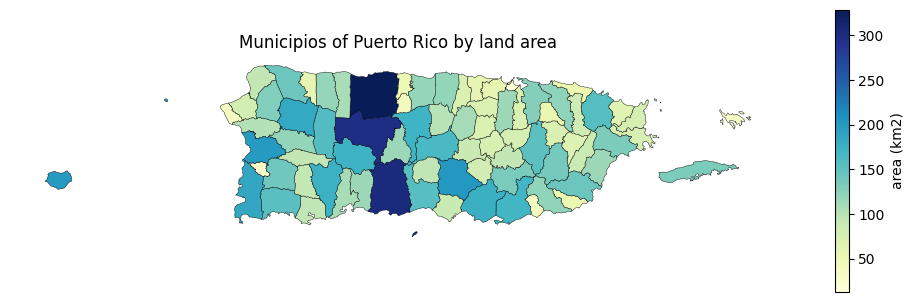

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
municipios.plot(column="area_km2", cmap="YlGnBu", legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": "area (km2)", "shrink": 0.6})
ax.set_axis_off()
ax.set_title("Municipios of Puerto Rico by land area")
plt.tight_layout()
plt.show()

> **Read it:** dark blue = big. Arecibo and the mountainous interior
> municipios stand out; the metro-area municipios around San Juan are small
> and pale. This map is honest because its variable *is* area -- but notice
> how strongly your eye equates dark with "important". That instinct is what
> the concept note's counts-vs-density pitfall is about, and we will meet it
> for real in Step 5.

## Step 4: Layering the Quakes (Worked + Completion)

Two layers on one map -- but Step 1 showed they live on different grids.
Align first, then plot polygons and points on the same axes:

In [7]:
print("Municipios CRS:", municipios.crs.to_epsg())
print("Quakes CRS:    ", quakes.crs.to_epsg())

quakes = quakes.to_crs(municipios.crs)
print("After to_crs:  ", quakes.crs.to_epsg())

Municipios CRS: 32161
Quakes CRS:     4979
After to_crs:   32161


<details><summary>Expected Output</summary>

~~~text
Municipios CRS: 32161
Quakes CRS:     4979
After to_crs:   32161
~~~
</details>

Mainshock: 4 km SSE of Indios, Puerto Rico | magnitude 6.4


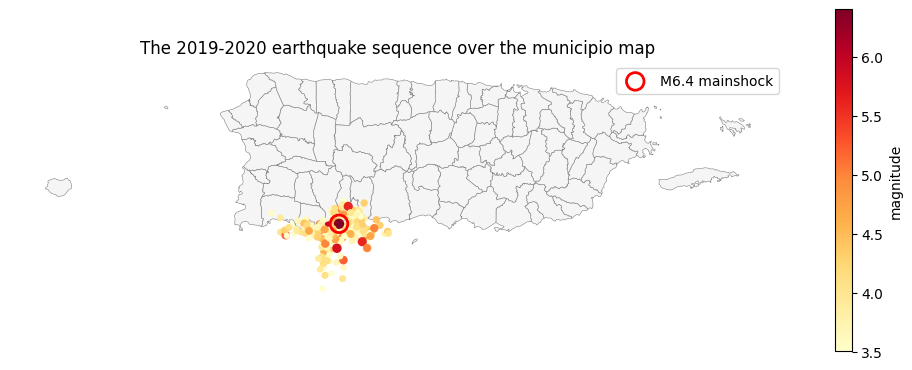

In [8]:
mainshock = quakes.loc[quakes["mag"].idxmax()]
print("Mainshock:", mainshock["place"], "| magnitude", mainshock["mag"])

fig, ax = plt.subplots(figsize=(10, 6))
municipios.plot(ax=ax, facecolor="whitesmoke", edgecolor="gray", linewidth=0.4)
quakes.plot(ax=ax, markersize=quakes["mag"] ** 2, column="mag", cmap="YlOrRd",
            legend=True, legend_kwds={"label": "magnitude", "shrink": 0.6})
ax.scatter(mainshock.geometry.x, mainshock.geometry.y, s=160, facecolor="none",
           edgecolor="red", linewidth=2, label="M6.4 mainshock")
ax.legend(loc="upper right")
ax.set_axis_off()
ax.set_title("The 2019-2020 earthquake sequence over the municipio map")
plt.tight_layout()
plt.show()

<details><summary>Expected Output</summary>

~~~text
Mainshock: 4 km SSE of Indios, Puerto Rico | magnitude 6.4
~~~
</details>

> **Read it:** the sequence snaps into focus: a tight cluster off the
> southwest coast, between Lajas and Ponce, most of it in the sea. The
> mainshock (red circle) sits just offshore, south of Guayanilla -- "4 km SSE
> of Indios" is a real place name from the USGS locator. Marker size and
> color both encode magnitude, so the handful of M5+ events jump out of the
> swarm of M3.5-4.5 aftershocks.

Your turn -- how many of these events were magnitude 5.0 or stronger?

In [9]:
# Uncomment and fill the ____ : filter the quakes table on its "mag" column.
# strong = quakes[quakes["mag"] >= ____]
# print(len(strong), "quakes at M5.0+")
# print(strong[["mag", "place"]].sort_values("mag", ascending=False).head())

<details><summary>Expected Output</summary>

~~~text
12 quakes at M5.0+
     mag                                  place
230  6.4        4 km SSE of Indios, Puerto Rico
139  5.9  5 km SE of Maria Antonia, Puerto Rico
236  5.8         14 km S of Indios, Puerto Rico
209  5.6   0 km NW of Magas Arriba, Puerto Rico
227  5.6       11 km S of Tallaboa, Puerto Rico
~~~
*(Twelve M5+ events in five weeks -- and every place name in the top five is
on the same short stretch of southwest coast.)*
</details>

## Step 5: The Spatial Join -- Which Municipio Shook Most? (Worked)

A regular merge lines up rows by a shared key. A **spatial join** lines them
up by *location*: each quake gets the columns of the municipio whose polygon
contains it.

In [10]:
located = gpd.sjoin(quakes, municipios[["NAMELSADCO", "area_km2", "geometry"]],
                    how="left", predicate="within")
onshore = located["NAMELSADCO"].notna().sum()
print(f"Epicenters on land: {onshore} of {len(located)} -- the rest were offshore")

counts = (located.groupby("NAMELSADCO").size()
          .rename("n_quakes").sort_values(ascending=False))
print()
print(counts.head(6))

Epicenters on land: 56 of 250 -- the rest were offshore

NAMELSADCO
Guánica Municipio       18
Guayanilla Municipio    17
Peñuelas Municipio      10
Yauco Municipio          8
Lajas Municipio          2
Ponce Municipio          1
Name: n_quakes, dtype: int64


<details><summary>Expected Output</summary>

~~~text
Epicenters on land: 56 of 250 -- the rest were offshore

NAMELSADCO
Guánica Municipio       18
Guayanilla Municipio    17
Peñuelas Municipio      10
Yauco Municipio          8
Lajas Municipio          2
Ponce Municipio          1
Name: n_quakes, dtype: int64
~~~
</details>

> **Read it:** the join's unmatched rows are findings, not failures: 194 of
> the 250 epicenters fall inside *no* municipio -- the sequence was mostly
> under the sea, which the overlay map already hinted at. Among the 56
> onshore events, the ranking reads like the news reports from January 2020:
> Guanica and Guayanilla first, then Penuelas and Yauco. The data and the
> lived experience agree.

Now turn the counts into a per-municipio map. First the counts have to get
back onto the boundary table -- an ordinary key-based merge does it: match
each boundary row to its entry in `counts` by municipio name (`left_on=` the
name column, `right_index=` because `counts` is indexed by name), keeping
all 78 municipios (`how="left"`; the 72 with no match get NaN, hence
`fillna(0)`).

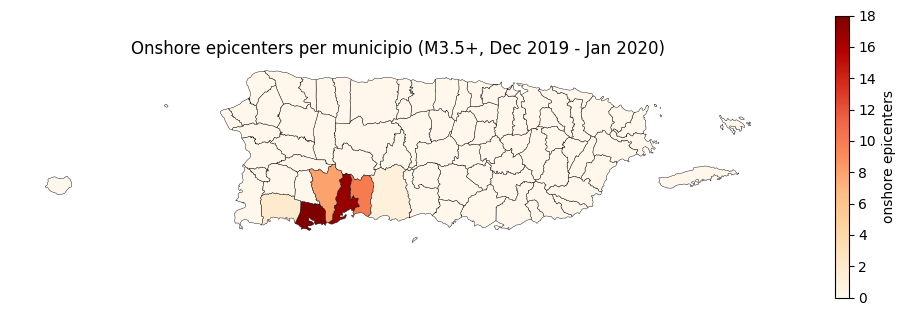

In [11]:
if "n_quakes" not in municipios.columns:   # guard: safe to re-run this cell
    municipios = municipios.merge(counts, left_on="NAMELSADCO",
                                  right_index=True, how="left")
municipios["n_quakes"] = municipios["n_quakes"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
municipios.plot(column="n_quakes", cmap="OrRd", legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": "onshore epicenters", "shrink": 0.6})
ax.set_axis_off()
ax.set_title("Onshore epicenters per municipio (M3.5+, Dec 2019 - Jan 2020)")
plt.tight_layout()
plt.show()

> **Read it:** 72 of the 78 municipios are pale zero; the entire signal lives
> in six adjacent municipios in the southwest corner. A choropleth like this
> -- mostly empty with one hot corner -- is itself a finding: the sequence
> was intensely local. Before quoting the dark values, though, remember Step
> 3: these are raw *counts*, and municipios differ 25-fold in size. Exercise
> 1 fixes that.

Want to zoom and hover? GeoDataFrames also produce interactive maps -- try
this in Colab (it needs the `folium` package and renders a pannable map, so
we leave it out of the static notebook):

~~~python
municipios.explore(column="n_quakes", cmap="OrRd", legend=True,
                   tooltip=["NAMELSADCO", "n_quakes", "area_km2"])
~~~

## Your Turn (Exercises)

### Exercise 1 -- Normalize the choropleth

Step 5's map shows raw counts; municipios differ 25-fold in area. Add a
`quakes_per_100km2` column (counts divided by area, times 100), map it, and
print the top four municipios with their counts, areas, and densities. One
sentence: what does the density map say that the count map cannot?

> **Hint:** `municipios["n_quakes"] / municipios["area_km2"] * 100`, then the
> same `.plot(column=...)` pattern as Step 5.

In [12]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
          NAMELSADCO  n_quakes  area_km2  quakes_per_100km2
   Guánica Municipio      18.0     96.12              18.73
Guayanilla Municipio      17.0    109.62              15.51
  Peñuelas Municipio      10.0    115.65               8.65
     Yauco Municipio       8.0    176.73               4.53
~~~
*(The ranking happens to hold -- the hardest-hit municipios are also small --
but the numbers change meaning: 18.73 epicenters per 100 km2 says Guanica
was not just hit often, it was SATURATED: nearly one epicenter for every
5 km2 of territory.)*
</details>

### Exercise 2 -- How far was your municipio?

Compute each municipio's distance to the mainshock: take the municipio
centroids, measure the distance to `mainshock.geometry`, convert to km, and
map it. Then print the distance for Humacao (where this course is taught)
and for the closest municipio. One sentence on the pattern.

> **Hint:** `municipios.geometry.centroid.distance(mainshock.geometry) / 1000`
> -- this works because everything is already in meters (EPSG:32161).

In [13]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
Humacao centroid to the mainshock: 108.0 km
Closest: Guayanilla Municipio at 9.4 km
~~~
*(The distance map is a smooth gradient radiating from the southwest corner
-- Guayanilla at 9 km, Humacao at 108 km, Culebra at 166 km. That gradient
is roughly the order in which the island felt the shaking weaken.)*
</details>

### Exercise 3 -- Written: pick the one graphic

A newsroom can print ONE graphic for the story "where the earthquake
sequence hit". The candidates: Step 4's point map, Step 5's raw-count
choropleth, or Exercise 1's density choropleth. Argue for one, in 3-4
sentences, naming one strength of your choice and one honest weakness --
and use a fact from this lab as evidence.

> **Hint:** which audience question does each map answer -- "where were the
> events", "which municipios", or "how intense per area"? And which map can
> show the 194 offshore epicenters at all?

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| Load spatial data | `gpd.read_file` (zip or GeoJSON) | A GeoDataFrame is a table plus a geometry column |
| Fix the coordinates | `.crs`, `to_crs(epsg=32161)` | Degrees store, meters measure (0.7626 vs 8,928 km2) |
| Merge shapes | `dissolve(by="NAMELSADCO")` | 901 barrios -> the 78 municipios |
| Choropleth | `.plot(column=, legend=True)` | Dark reads as "more" -- choose the variable honestly |
| Layer datasets | two `.plot(ax=ax)` calls, shared CRS | The sequence clusters off the southwest coast |
| Join by location | `gpd.sjoin(..., predicate="within")` | 56 of 250 epicenters onshore; Guanica hit hardest |

Next lesson (L13): patterns in *time* -- trends, seasonality, and how to
plot a variable that moves.